# MNIST Digits - Keras Demo
A demo of MLP using Python and Keras.

Extension of code generated by Gemini.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt # for plotting
print("Imports done.")

Imports done.


In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize the pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
count=len(y_train)
print(f"Num training samples: {count:,} (used for training and validation)")
count=len(y_test)
print(f"Num test samples: {count:,} (saved for the very last test)")
print("Data loaded.")

Num training samples: 60,000 (used for training and validation)
Num test samples: 10,000 (saved for the very last test)
Data loaded.


## Design the Model

In [3]:
# The Sequential class builds a layered, feed-forward neural network.
# Choose layer hyperparameters: neurons per layer, and activation function per layer.
model = Sequential([
    Flatten(input_shape=(28, 28)),          # Flattens the 28x28 2D pixel arrays into 1D vectors
    Dense(512, activation='relu'),          # Hidden layer with 512 nodes
    Dense(10, activation='softmax')         # Output layer for the 10 digits (0-9)
])
# Choose hyperparameters for training.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Train the Model

In [4]:
# Choose train hyperparameters: num epochs, percent held out for validation
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9362 - loss: 0.2201 - val_accuracy: 0.9668 - val_loss: 0.1108
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9734 - loss: 0.0877 - val_accuracy: 0.9678 - val_loss: 0.1036
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9829 - loss: 0.0560 - val_accuracy: 0.9734 - val_loss: 0.0919
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9881 - loss: 0.0386 - val_accuracy: 0.9742 - val_loss: 0.0869
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9913 - loss: 0.0285 - val_accuracy: 0.9778 - val_loss: 0.0822


## Plot the Training History

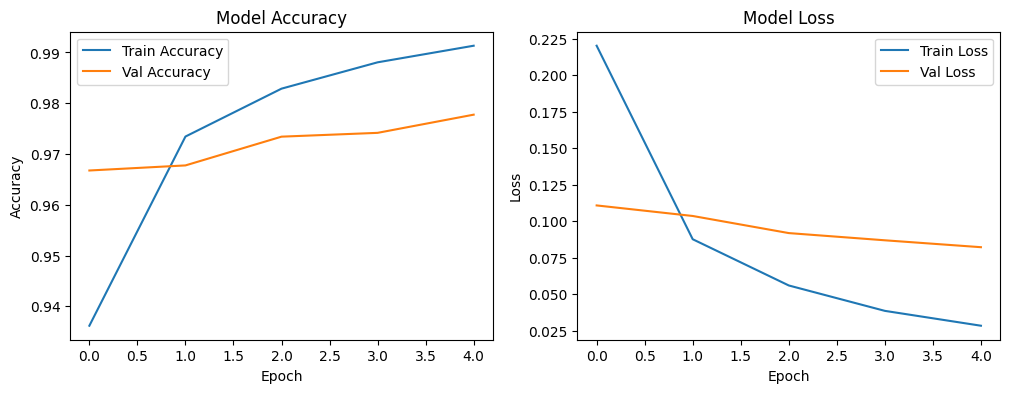

In [5]:
plt.figure(figsize=(12, 4)) 
# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
# Turn on the display
plt.show()

# Test the Model
So far, all results reflect the training set.
The test set has not been consulted at all.

To be fair, the test set should be used only once.
If we're happy with our model, let's run the test.

In [6]:
def show_results(label,loss,acc):
    acc_pct = 100.0*acc
    print(label, "---")
    print (f"Loss: {loss:.5f}, Acc: {acc_pct:.2f}%")

In [7]:
# The data arrived in two parts: training and test.
# Above, 20% of the training set was withheld for validation.
# Here, evaluate model on 100% of the training set.
# Numerator & denominator on the left show amount tested so far, in batches.
train_loss,train_acc = model.evaluate(x_train, y_train)
show_results("Train",train_loss,train_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 460us/step - accuracy: 0.9912 - loss: 0.0312
Train ---
Loss: 0.03115, Acc: 99.12%


In [8]:
# For the first time, evaluate model on the test set.
test_loss,test_acc = model.evaluate(x_test, y_test)
show_results("Test",test_loss,test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.9779 - loss: 0.0750
Test ---
Loss: 0.07503, Acc: 97.79%
